In [22]:
import pandas as pd
import glob
import re
from pymatgen.core import Composition
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import os

In [23]:
targetdir = "../../data/"
if not os.path.isdir(targetdir):
    print("taretdir",targetir,"not found.")
    raise

In [24]:
def get_formula_sg(filename):
    df = pd.read_csv(filename,skiprows=10)
    nelm = []
    for formula in df["formula"]:
        formula = formula.replace("-","")
        s = formula.split()
        nelm .append(len(s))
    df["nelm"] = nelm
    dfq = df.query("nelm==2")[["formula","sg"]]
    return dfq

In [25]:
def get_files_all(globpath="CODdata/*.csv"):
    """
    get data from COD at Nov. 10, 2021
    """
    files = glob.glob(globpath)
    dflist = []
    for file in files:
        dfq= get_formula_sg(file)
        if dfq is not None:
            dflist.append(dfq)
    dfresult = pd.concat(dflist,axis=0).reset_index(drop=True)
    return dfresult.drop_duplicates()

df2elm = get_files_all()
df2elm

,formula,sg
0,- In P -,F -4 3 m
1,- In P3 -,R -3 m :H
3,- In P -,F m -3 m
6,- Ga P -,F -4 3 m
7,- Ge P3 -,R -3 m :H
8,- Ge P -,I 4 m m
9,- Ge P -,C 1 2/m 1
10,- Ga0.071 Sn0.929 -,I 41/a m d :1
11,- Al Sb -,F -4 3 m
14,- P Si -,F -4 3 m


In [26]:
def fix_df(df):
    formula_list = []
    for formula in df["formula"]:
        formula = formula.replace("-","").replace(" ","")
        formula_list.append(formula)
    sg_list = []
    for sg in df["sg"]:
        sg = re.sub(":.*$","",sg)
        sg = sg.replace(" ","")
        sg_list.append(sg)

    df_formula= pd.DataFrame({"formula": formula_list,"sg": sg_list})
    
    comp_list = []
    for formula in df_formula["formula"]:
        composition = Composition(formula)
        d = composition.as_dict()
        comp = []
        for key, value in d.items():
            comp.extend([key,value])
        comp_list.append(comp)
    df_comp = pd.DataFrame(comp_list, columns=["elm1","formula_n1","elm2","formula_n2"])
    
    n1n2_list = []
    for n1n2 in  df_comp[["formula_n1","formula_n2"]].values:
        s = n1n2.sum()
        n1n2 = n1n2/s*10
        n1n2_list.append(n1n2)
    df_n1n2 =pd.DataFrame(n1n2_list, columns=["nr1","nr2"])
    df_n1n2 = df_n1n2.round().astype(int)
    df_frac = pd.concat([df_formula, df_comp,df_n1n2], axis=1)  
    
    return df_frac

df_frac= fix_df(df2elm)

In [27]:
df_frac.to_csv(os.path.join(targetdir,"group131415_elm1elm2.csv"),index=False)

In [28]:
df_frac

,formula,sg,elm1,formula_n1,elm2,formula_n2,nr1,nr2
0,InP,F-43m,In,1.0000,P,1.0000,5,5
1,InP3,R-3m,In,1.0000,P,3.0000,2,8
2,InP,Fm-3m,In,1.0000,P,1.0000,5,5
3,GaP,F-43m,Ga,1.0000,P,1.0000,5,5
4,GeP3,R-3m,Ge,1.0000,P,3.0000,2,8
5,GeP,I4mm,Ge,1.0000,P,1.0000,5,5
6,GeP,C12/m1,Ge,1.0000,P,1.0000,5,5
7,Ga0.071Sn0.929,I41/amd,Ga,0.0710,Sn,0.9290,1,9
8,AlSb,F-43m,Al,1.0000,Sb,1.0000,5,5
9,PSi,F-43m,P,1.0000,Si,1.0000,5,5


['Al^As', 'Al^Ge', 'Al^P', 'Al^Sb', 'As^Al', 'As^Ga', 'As^Ge', 'As^In', 'As^Sb', 'As^Si', 'As^Sn', 'Ga^As', 'Ga^Ge', 'Ga^In', 'Ga^P', 'Ga^Sb', 'Ga^Sn', 'Ge^Al', 'Ge^As', 'Ge^Ga', 'Ge^P', 'Ge^Sb', 'In^As', 'In^Ga', 'In^P', 'In^Sb', 'In^Sn', 'P^Al', 'P^Ga', 'P^Ge', 'P^In', 'P^Si', 'P^Sn', 'Sb^Al', 'Sb^As', 'Sb^Ga', 'Sb^Ge', 'Sb^In', 'Sb^Sn', 'Si^As', 'Si^P', 'Sn^As', 'Sn^Ga', 'Sn^In', 'Sn^P', 'Sn^Sb']
['0^10^Fd-3m', '0^10^I4/mmm', '10^0^Fd-3m', '10^0^I4/mmm', '1^9^Cmcm', '1^9^F-43m', '1^9^I4/mcm', '1^9^I4/mmm', '1^9^I41/amd', '2^8^I4/mmm', '2^8^I41/amd', '2^8^R-3m', '3^7^P63/mmc', '3^7^Pa-3', '4^6^I41/amd', '4^6^R-3m', '5^5^C12/m1', '5^5^Cmc21', '5^5^F-43m', '5^5^Fm-3m', '5^5^I41/amd', '5^5^I4mm', '5^5^P6/mmm', '5^5^Pm-3m', '5^5^Pmm2', '5^5^Pmmn', '5^5^R-3m', '6^4^I41/amd', '6^4^R-3m', '7^3^P63/mmc', '7^3^Pa-3', '8^2^I4/mmm', '8^2^I41/amd', '8^2^R-3m', '9^1^Cmcm', '9^1^F-43m', '9^1^I4/mcm', '9^1^I4/mmm', '9^1^I41/amd']


<AxesSubplot:>

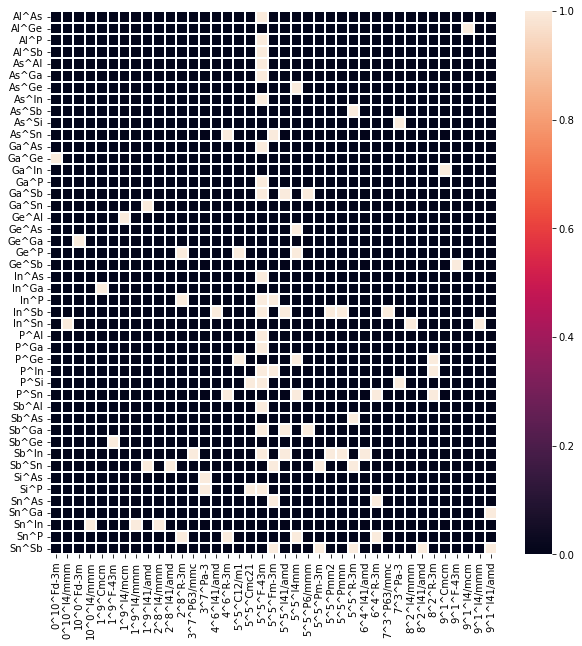

In [29]:
def get_two_features(df_frac, columns = ["elm1","elm2","nr1","nr2","sg"],
features1 = [[0,1],[1,0]], features2 = [[2,3,4],[3,2,4]] ):

    x1list = []
    x2list = []
    for line in df_frac[columns].values:
        line = list(map(str,line))
        for feature1, feature2 in zip(features1,features2):
            x1 = "^".join([line[x] for x in  feature1])
            x2 = "^".join([line[x] for x in  feature2])
            x1list.append(x1)
            x2list.append(x2)

    x1uniqlist = np.unique(x1list).tolist()
    x2uniqlist = np.unique(x2list).tolist()
    print(x1uniqlist)
    print(x2uniqlist)
    existmap =  np.zeros( (len(x1uniqlist), len(x2uniqlist) ) )

    for x1 , x2 in zip(x1list, x2list):
        i1 = x1uniqlist.index(x1)
        i2 =  x2uniqlist.index(x2)
        existmap[i1,i2] = 1

    df_emap =pd.DataFrame(existmap, index=x1uniqlist, columns=x2uniqlist)
    return df_emap


df_emap = get_two_features(df_frac)
fileout = os.path.join(targetdir,"group131415_div1.csv")
df_emap.to_csv(fileout)
df_emap2 = pd.read_csv(fileout, index_col=[0])
fig, ax = plt.subplots(figsize=(10,10))

sns.heatmap(df_emap2,ax=ax, linewidth=0.1)

['Al^As', 'Al^Ge', 'Al^P', 'Al^Sb', 'As^Ga', 'As^Ge', 'As^In', 'As^Sb', 'As^Si', 'As^Sn', 'Ga^Ge', 'Ga^In', 'Ga^P', 'Ga^Sb', 'Ga^Sn', 'Ge^P', 'Ge^Sb', 'In^P', 'In^Sb', 'In^Sn', 'P^Si', 'P^Sn', 'Sb^Sn']
['0^10', '1^9', '2^8', '4^6', '5^5', '6^4', '7^3', '8^2', '9^1']


<AxesSubplot:>

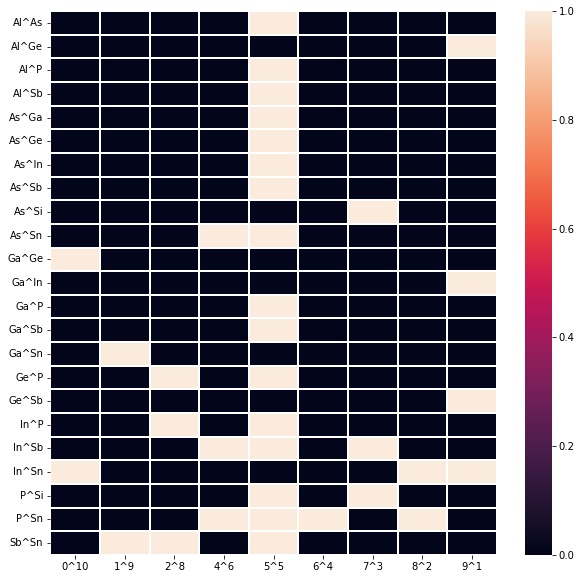

In [30]:
def get_two_features(df_frac, feature1 , feature2 ):

    x1list = []
    x2list = []
    for line in df_frac[feature1].values:
        line = list(map(str,line))
        x1 = "^".join(line)
        x1list.append(x1)
        
    for line in df_frac[feature2].values:
        line = list(map(str,line))
        x2 = "^".join(line)
        x2list.append(x2)

    x1uniqlist = np.unique(x1list).tolist()
    x2uniqlist = np.unique(x2list).tolist()
    print(x1uniqlist)
    print(x2uniqlist)
    existmap =  np.zeros( (len(x1uniqlist), len(x2uniqlist) ) )

    for x1 , x2 in zip(x1list, x2list):
        i1 = x1uniqlist.index(x1)
        i2 =  x2uniqlist.index(x2)
        existmap[i1,i2] = 1

    df_emap =pd.DataFrame(existmap, index=x1uniqlist, columns=x2uniqlist)
    return df_emap

feature1 = ["elm1","elm2"]
feature2 = ["nr1","nr2"]
df_emap = get_two_features(df_frac, feature1=feature1, feature2=feature2)
fileout = os.path.join(targetdir,"group131415_div2.csv")
df_emap.to_csv(fileout)
df_emap2 = pd.read_csv(fileout, index_col=[0])

fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(df_emap2,ax=ax, linewidth=0.1)